In [1]:
from plot_tmi_results import compute_tmi_from_singular_values
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import h5py
import csv
from FSS.DataCollapse import *

In [2]:
def read_tmi_results_to_df(p_fixed, p_fixed_name, L_values=None, n=0, threshold=1e-10):
    """
    Read singular values from HDF5 files, compute TMI statistics, and return results as a DataFrame.
    Scans for all available data files with different p_c values and combines them into one CSV.
    
    Parameters:
    -----------
    p_fixed : float
        Fixed parameter value
    p_fixed_name : str
        Name of fixed parameter ('pproj' or 'pctrl')
    L_values : list, optional
        List of L values to process. If None, discovers all available L values.
    n : int, optional
        Parameter for TMI computation
    threshold : float, optional
        Threshold for TMI computation
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with MultiIndex (p, L) containing TMI observations
    """
    import glob
    # Find all relevant data files using glob
    file_pattern = f'tmi_fine_L*_{p_fixed_name}{p_fixed:.3f}_pc*'
    all_files = glob.glob(file_pattern)
    
    # Extract unique L values and p_c values from filenames
    if L_values is None:
        L_values = sorted(list(set([int(f.split('_')[2][1:]) for f in all_files])))
    p_c_values = sorted(list(set([float(f.split('_pc')[1]) for f in all_files])))
    
    output_filename = f'tmi_results_combined_{p_fixed_name}{p_fixed:.3f}.csv'
    p_scan_name = 'pctrl' if p_fixed_name == 'pproj' else 'pproj'
    
    # If CSV exists, read directly from it
    if os.path.exists(output_filename):
        print(f"Reading existing results from {output_filename}")
        data_list = []
        with open(output_filename, mode='r') as file:
            reader = csv.DictReader(file)
            for row in reader:
                data_list.append({
                    'p': float(row[f'{p_scan_name}_value']),
                    'L': int(row['L']),
                    'observations': float(row['tmi_value'])
                })
    else:
        data_list = []
        
        # Write results to CSV and collect data for DataFrame
        with open(output_filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['L', p_fixed_name, p_scan_name + '_index', p_scan_name + '_value', 'p_c', 'sample_idx', 'tmi_value'])
            
            for L in L_values:
                for p_c in p_c_values:
                    filename = f'tmi_fine_L{L}_{p_fixed_name}{p_fixed:.3f}_pc{p_c}/final_results_L{L}.h5'
                    if not os.path.exists(filename):
                        print(f"Warning: File {filename} not found!")
                        continue
                        
                    print(f"\nAnalyzing file: {filename}")
                    with h5py.File(filename, 'r') as f:
                        p_fixed_key = f"{p_fixed_name}{p_fixed:.3f}"
                        p_fixed_group = f[p_fixed_key]
                        p_scan_values = p_fixed_group[p_scan_name][:]
                        sv_group = p_fixed_group['singular_values']
                        
                        num_p_scan = len(p_fixed_group[p_scan_name])
                        
                        for p_scan_idx in range(num_p_scan):
                            num_samples = sv_group[list(sv_group.keys())[0]].shape[1]
                            singular_values = [{
                                key: sv_group[key][p_scan_idx, sample_idx] 
                                for key in sv_group.keys()
                            } for sample_idx in range(num_samples)]
                            
                            # Compute TMI for each sample
                            tmi_values = [compute_tmi_from_singular_values(sv, n, threshold) 
                                        for sv in singular_values]
                            
                            # Write to CSV and collect for DataFrame
                            for sample_idx, tmi_value in enumerate(tmi_values):
                                writer.writerow([L, p_fixed_key, p_scan_idx, p_scan_values[p_scan_idx], p_c, sample_idx, tmi_value])
                                data_list.append({
                                    'p': p_scan_values[p_scan_idx],
                                    'L': L,
                                    'p_c': p_c,
                                    'observations': tmi_value
                                })
    

    # Create DataFrame and group observations
    df = pd.DataFrame(data_list)
    df_grouped = df.groupby(['p', 'L'])['observations'].apply(list).reset_index()
    df_final = df_grouped.set_index(['p', 'L'])
    
    return df_final


In [3]:
p_fixed = 0.643
p_c = 0.473
delta_p = 0.045
L_min = 16
df = read_tmi_results_to_df(p_fixed, p_fixed_name = 'pproj', L_values = [8, 12, 16, 20], threshold=1e-10)
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[p_c - delta_p, p_c + delta_p],Lmin=L_min)
dc.datacollapse(p_c=p_c,nu=1,beta=0.,p_c_vary=True,beta_vary=False,nu_vary=True, max_nfev=1000)

Reading existing results from tmi_results_combined_pproj0.643.csv


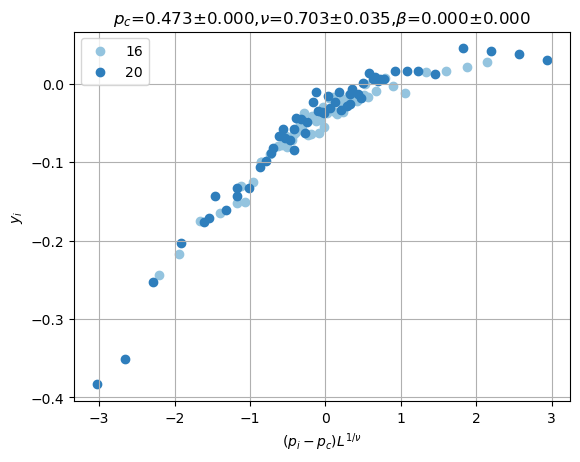

In [4]:
dc.plot_data_collapse()

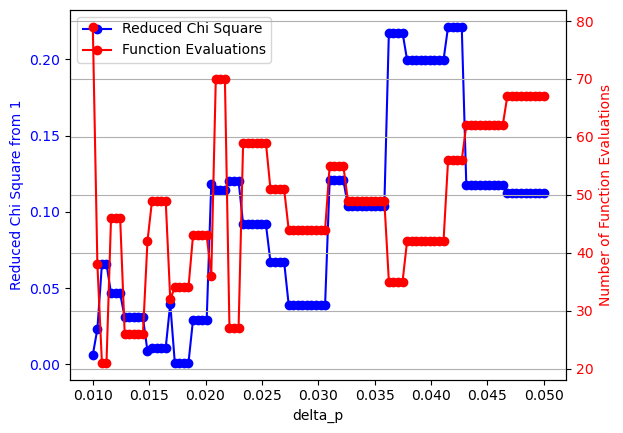

In [5]:
delta_p_values = np.linspace(0.01, 0.05, 100)
redchi_values = []
num_func_evals = []

for delta_p in delta_p_values:
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=1, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    redchi_values.append(dc.res.redchi)
    num_func_evals.append(dc.res.nfev)
fig, ax1 = plt.subplots()

# Plot redchi on left y-axis
ax1.plot(delta_p_values, abs(1-np.array(redchi_values)), 'o-', color='blue', label='Reduced Chi Square')
ax1.set_xlabel('delta_p')
ax1.set_ylabel('Reduced Chi Square from 1', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot nfev
ax2 = ax1.twinx()
ax2.plot(delta_p_values, num_func_evals, 'o-', color='red', label='Function Evaluations')
ax2.set_ylabel('Number of Function Evaluations', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid()
plt.show()

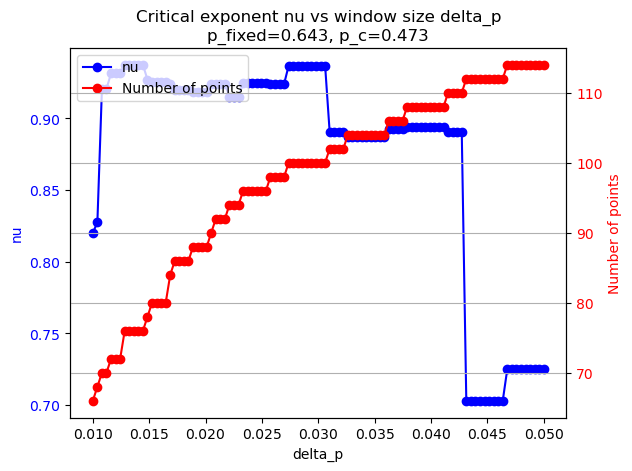

In [6]:
# Extract nu values and number of points for different delta_p
nu_values = []
num_points = []
for delta_p in delta_p_values:
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=1, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    nu_values.append(dc.nu)
    num_points.append(len(dc.y_i))

fig, ax1 = plt.subplots()

# Plot nu on left y-axis
ax1.plot(delta_p_values, nu_values, 'o-', color='blue', label='nu')
ax1.set_xlabel('delta_p')
ax1.set_ylabel('nu', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot number of points
ax2 = ax1.twinx()
ax2.plot(delta_p_values, num_points, 'o-', color='red', label='Number of points')
ax2.set_ylabel('Number of points', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Critical exponent nu vs window size delta_p\np_fixed={p_fixed:.3f}, p_c={p_c:.3f}')
plt.grid()
plt.show()


In [7]:
df_ = df.map(np.mean)
df_std = df.map(lambda x: np.std(x)/np.sqrt(len(x)))

In [8]:
df_.index.get_level_values('p').unique().size

59

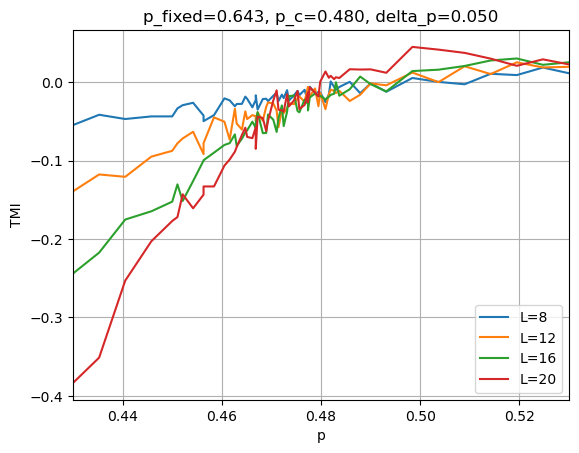

In [19]:
delta_p = 0.05
p_c = 0.48
p_range = [p_c - delta_p,p_c + delta_p]
fig,ax=plt.subplots()
for L in [8,12,16,20]:
    ax.plot(df_.index.get_level_values('p').unique(),df_['observations'].xs(L,level='L'),label=f'L={L}')
ax.legend()
ax.set_xlabel('p')
ax.set_ylabel('TMI')
ax.set_title(f'p_fixed={p_fixed:.3f}, p_c={p_c:.3f}, delta_p={delta_p:.3f}')
ax.set_xlim(p_range)
ax.grid()
plt.show()

In [ ]:
# check whether i am doing the ensemble average correctly
# then report to Haining that the nu equals to 0.7 result does not correspond to the best fit, where as the 
# best fit according to the reduced chi square is 0.9

In [10]:
# try larger sample size
# denser p scan resolutions closer to pc
# try different threshold -- as related to pc and nu